In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

%matplotlib inline

In [2]:
df = pd.read_csv("b2_experiment.csv")
df

,Unnamed: 0,ionic_strength,B2,B2_error,[NaCl],molecule,label,Mw,pH,shortdoi
0,0,0.010000,0.002577,0.000130,0.010000,lysozyme,ivinterbladh2025,14300,7.0,NaN
1,1,0.011000,0.002085,0.000061,0.011000,lysozyme,ivinterbladh2025,14300,7.0,NaN
2,2,0.012000,0.001788,0.000065,0.012000,lysozyme,ivinterbladh2025,14300,7.0,NaN
3,3,0.014000,0.001519,0.000047,0.014000,lysozyme,ivinterbladh2025,14300,7.0,NaN
4,4,0.018000,0.001127,0.000063,0.018000,lysozyme,ivinterbladh2025,14300,7.0,NaN
5,5,0.020000,0.000977,0.000062,0.020000,lysozyme,ivinterbladh2025,14300,7.0,NaN
6,6,0.025000,0.000663,0.000044,0.025000,lysozyme,ivinterbladh2025,14300,7.0,NaN
7,7,0.030000,0.000536,0.000041,0.030000,lysozyme,ivinterbladh2025,14300,7.0,NaN
8,8,0.035000,0.000396,0.000036,0.035000,lysozyme,ivinterbladh2025,14300,7.0,NaN
9,9,0.040000,0.000292,0.000016,0.040000,lysozyme,ivinterbladh2025,14300,7.0,NaN


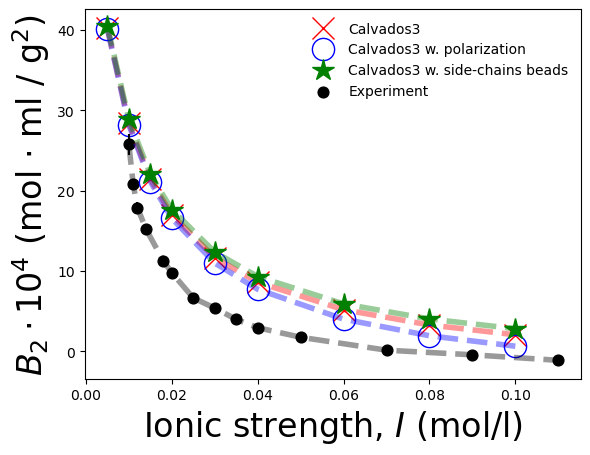

In [3]:
def plot_lysozyme(ax):
    Ion, B2 = np.loadtxt("lysozyme_pH7_vanilla/b2.dat", unpack=True)
    ax.plot(Ion / 1e3, B2 * 1e4, "rx", label="Calvados3", markersize=16)
    ax.plot(Ion / 1e3, B2 * 1e4, "r--", label=None, alpha=0.4, linewidth=4)

    Ion, B2 = np.loadtxt("lysozyme_pH7_alpha/b2.dat", unpack=True)
    ax.plot(
        Ion / 1e3,
        B2 * 1e4,
        "bo",
        markerfacecolor="none",
        label="Calvados3 w. polarization",
        markersize=16,
    )
    ax.plot(Ion / 1e3, B2 * 1e4, "b--", label=None, alpha=0.4, linewidth=4)

    Ion, B2 = np.loadtxt("lysozyme_pH7_sidechain/b2.dat", unpack=True)
    ax.plot(Ion/ 1e3, B2 * 1e4, "g*", label="Calvados3 w. side-chains beads", markersize=16)
    ax.plot(Ion/ 1e3, B2 * 1e4, "g--", label=None, alpha=0.4, linewidth=4)

    sel = (df.pH == 7.0) & (df.molecule == "lysozyme")
    exp = df[sel].copy(deep=True)
    exp["B2"] = exp["B2"] * 1e4
    exp["B2_error"] = exp["B2_error"] * 1e4
    
    exp.plot.scatter(
        "ionic_strength",
        "B2",
        yerr="B2_error",
        color="k",
        label="Experiment",
        ax=ax,
        s=60,
    )
    exp.plot(
        "ionic_strength", "B2", style="k--", kind="line", ax=ax, alpha=0.4, label="", linewidth=4
    )

    ax.set_xlabel(r"Ionic strength, $I$ (mol/l)", fontsize=24)
    ax.set_ylabel(r"$B_2\cdot 10^4$ (mol $\cdot$ ml / g$^2$)", fontsize=24)
    ax.legend(frameon=False)


fig, ax = plt.subplots()
plot_lysozyme(ax)

    Unnamed: 0  ionic_strength     B2  B2_error    [NaCl]  \
36          36        0.009216 -3.270     0.295  0.009216   
37          37        0.011216 -4.320     0.380  0.011216   
38          38        0.014216 -4.070     0.250  0.014216   
39          39        0.019216 -3.370     0.150  0.019216   
40          40        0.024216 -2.930     0.275  0.024216   
41          41        0.029216 -1.940     0.120  0.029216   
42          42        0.034216 -2.070     0.165  0.034216   
43          43        0.049216 -1.850     0.070  0.049216   
44          44        0.069216 -1.250     0.140  0.069216   
45          45        0.089216 -1.250     0.100  0.089216   
46          46        0.109216 -0.852     0.150  0.109216   

                molecule             label     Mw   pH shortdoi  
36  α-chymotrypsinogen A  ivinterbladh2025  26863  7.0      NaN  
37  α-chymotrypsinogen A  ivinterbladh2025  26359  7.0      NaN  
38  α-chymotrypsinogen A  ivinterbladh2025  26690  7.0      NaN  
39 

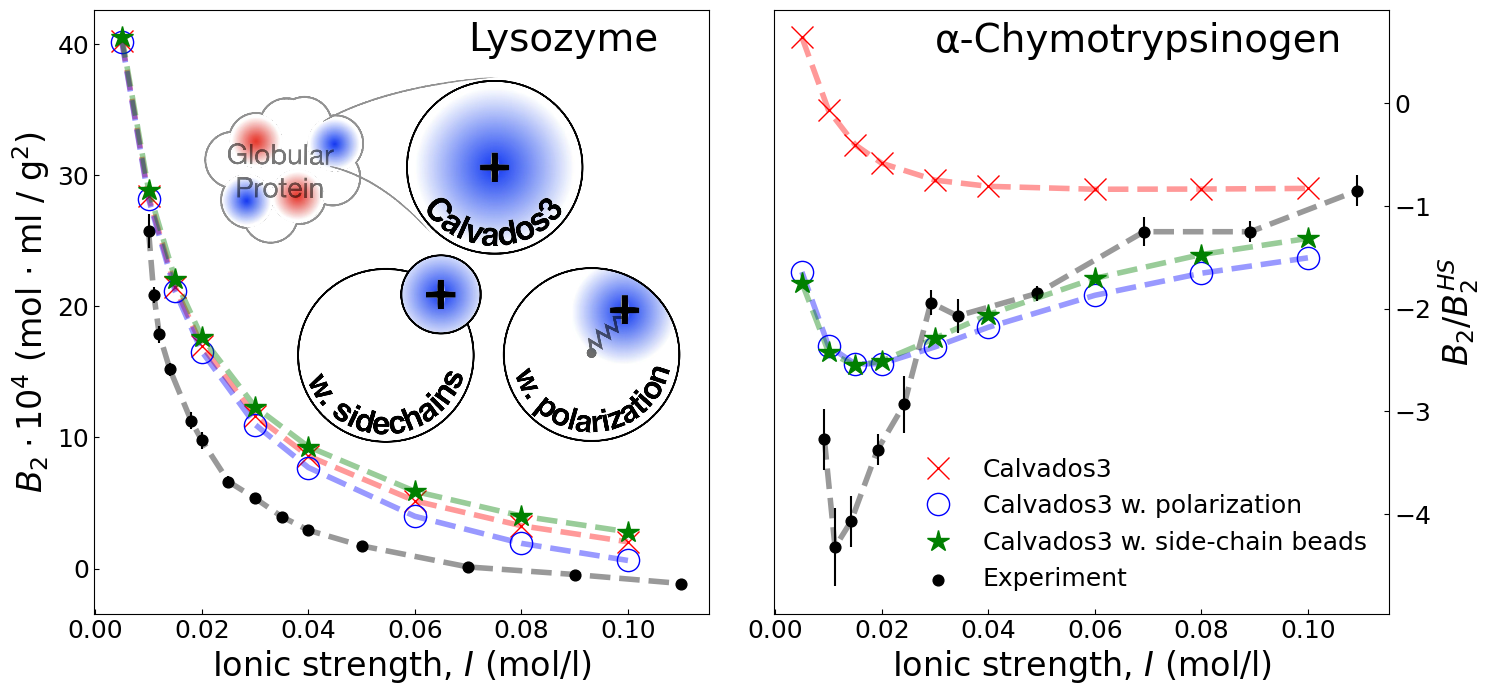

In [8]:
def plot_cgn(ax):
    Ion, B2 = np.loadtxt("cgn_pH7_vanilla/b2.dat", unpack=True)
    ax.plot(Ion/ 1e3, B2 * 1e4, "rx", label="Calvados3", markersize=16)
    ax.plot(Ion/ 1e3, B2 * 1e4, "r--", label=None, alpha=0.4, linewidth=4)

    Ion, B2 = np.loadtxt("cgn_pH7_alpha/b2.dat", unpack=True)
    ax.plot(
        Ion/ 1e3,
        B2 * 1e4,
        "bo",
        markerfacecolor="none",
        label="Calvados3 w. polarization", markersize=16
    )
    ax.plot(Ion/ 1e3, B2 * 1e4, "b--", label=None, alpha=0.4, linewidth=4)

    Ion, B2 = np.loadtxt("cgn_pH7_sidechain/b2.dat", unpack=True)
    ax.plot(Ion/ 1e3, B2 * 1e4, "g*", label="Calvados3 w. side-chain beads", markersize=16)
    ax.plot(Ion/ 1e3, B2 * 1e4, "g--", label=None, alpha=0.4, linewidth=4)

    sel = (df.pH == 7.0) & (df.molecule == "α-chymotrypsinogen A")
    exp = df[sel].copy(deep=True)
    exp["B2"] = exp["B2"] * 1e4
    exp["B2_error"] = exp["B2_error"] * 1e4
    print(exp)
    exp.plot.scatter(
        "ionic_strength",
        "B2",
        yerr="B2_error",
        color="k",
        s=60,
        label="Experiment",
        ax=ax,
       
    )
    exp.plot(
        "ionic_strength", "B2", style="k--", kind="line", linewidth=4, ax=ax, alpha=0.4, label=""
    )

    ax.set_xlabel(r"Ionic strength, $I$ (mol/l)", fontsize=24)
    #ax.set_ylabel(r"$B_2\cdot 10^4$ (mol $\cdot$ ml / g$^2$)", fontsize=24)
    ax.legend(frameon=False, loc=4, fontsize=18)


fig, ax = plt.subplots(1,2, figsize=(14, 7), sharex=True)
plot_lysozyme(ax[0])
plot_cgn(ax[1])
ax[0].legend().set_visible(False)
plt.tight_layout()
ax[0].yaxis.set_ticks_position("left")
ax[0].tick_params(direction="in", labelsize=18)
ax[1].yaxis.set_ticks_position("right")
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel(r"$B_2/B^{HS}_2$", fontsize=24)
ax[1].tick_params(direction="in", labelsize=18)
ax[0].text(0.07, 39.5, "Lysozyme", fontsize= 28)
ax[1].text(0.03, 0.5, "α-Chymotrypsinogen", fontsize= 28)
# ax[0].set_xscale("log")
# ax[1].set_xscale("log")

image = Image.open("calvados-models2.png")
imagebox = OffsetImage(
    image, zoom=0.26
)  # zoom scales the image while keeping aspect ratio
ab = AnnotationBbox(imagebox, (0.065, 23.5), frameon=False)  # position (x, y)
ax[0].add_artist(ab)
# ax[0].text(
#     0.05,
#     28.2,
#     "Charged\nresidue\nrepresentations",
#     fontsize="small",
#     fontstyle="italic",
#     ha="center",
#     va="center",
# )
plt.savefig("lys-cgn.pdf")
plt.show()